In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/tokenized_access_logs.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DescriptionDataCoSupplyChain.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')

cols_to_drop = ['Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 
                'Customer Street', 'Order Zipcode', 'Product Description', 'Product Image']

df_clean = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dataset successfully loaded with {df_clean.shape[0]} rows.")
print("-" * 30)
print("Delivery Status Breakdown:")
print(df_clean['Delivery Status'].value_counts())

Dataset successfully loaded with 180519 rows.
------------------------------
Delivery Status Breakdown:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


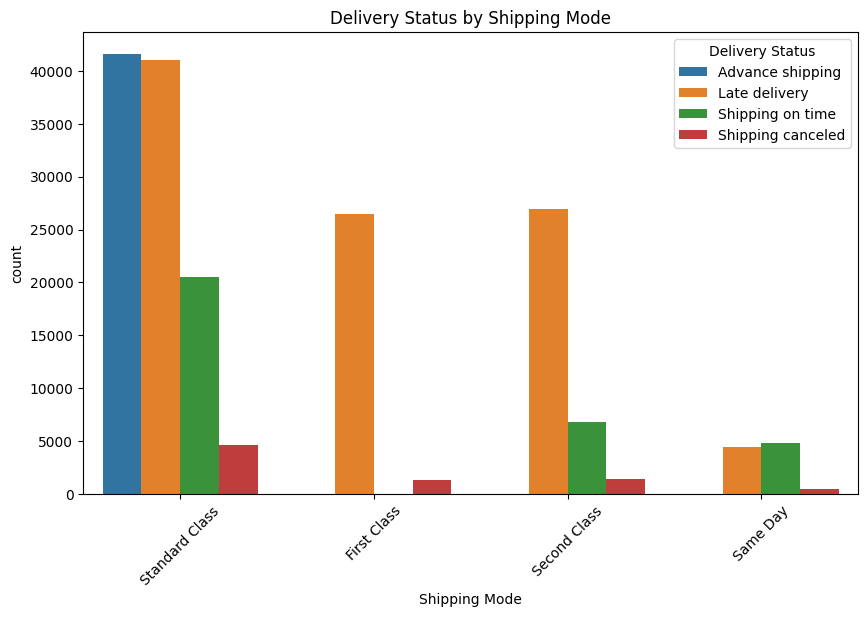

Top 5 Categories with highest Late Delivery Rate:
Category Name
Golf Bags & Carts    0.688525
Lacrosse             0.600583
Pet Supplies         0.589431
Cameras              0.581081
Strength Training    0.576577
Name: Delivery Status, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(x='Shipping Mode', hue='Delivery Status', data=df_clean)
plt.title('Delivery Status by Shipping Mode')
plt.xticks(rotation=45)
plt.show()

late_per_category = df_clean.groupby('Category Name')['Delivery Status'].apply(lambda x: (x == 'Late delivery').mean()).sort_values(ascending=False)
print("Top 5 Categories with highest Late Delivery Rate:")
print(late_per_category.head(5))

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

df_clean['is_late'] = (df_clean['Delivery Status'] == 'Late delivery').astype(int)

features = ['Shipping Mode', 'Category Name', 'Order Region', 'Days for shipping (real)', 'Days for shipment (scheduled)']
X = pd.get_dummies(df_clean[features]) # Convert text to numbers
y = df_clean['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)

y_pred = rf_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Cross-Validation Mean Score: {cv_scores.mean():.2f}")

Model Accuracy: 0.97
Cross-Validation Mean Score: 0.97
